<a href="https://colab.research.google.com/github/rajen1kgthb/UCI-X427.05/blob/main/M3-Assignment-UCI-SouthGermanCredit-DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install UCI repo package if not already present
!pip install ucimlrepo

In [3]:
#from ucimlrepo import fetch_ucirepo

# Fetch South German Credit dataset (ID: 522)
#south_german_credit = fetch_ucirepo(id=522)

# Load directly into pandas DataFrames
#X = south_german_credit.data.features
#y = south_german_credit.data.targets

# Merge into one DataFrame if preferred
#df = X.copy()
#df['kredit'] = y

#print(df.head())

In [4]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch South German Credit dataset (ID: 522)
south_german_credit = fetch_ucirepo(id=522)

# Load directly into pandas DataFrames
X = south_german_credit.data.features
y = south_german_credit.data.targets

# Merge into one DataFrame if preferred
df = X.copy()
df['kredit'] = y

# Verify dataframes printed successfully
print("--- Full Dataset Shape ---", df.shape)
print("\n--- Features (X) Head ---")
print(X.head())
print("\n--- Target (y) Class Balance ---")
print(y.value_counts())

HTTPError: HTTP Error 404: Not Found

In [5]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("sid321axn/south-german-credit-updated")

#print("Path to dataset files:", path)

100%|██████████| 20.4k/20.4k [00:00<00:00, 16.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sid321axn/south-german-credit-updated/versions/1


In [7]:
from google.colab import files
import pandas as pd

# 1. Trigger upload dialog (Select your local SouthGermanCredit.asc file)
uploaded = files.upload()

# 2. Read the uploaded file directly into Pandas
df = pd.read_csv("SouthGermanCredit.asc", sep=r"\s+")

# 3. Separate features and target
X = df.drop(columns=["kredit"])
y = df["kredit"]

print("\n--- Features Head ---")
print(X.head())

Saving SouthGermanCredit.asc to SouthGermanCredit (1).asc

--- Features Head ---
   laufkont  laufzeit  moral  verw  hoehe  sparkont  beszeit  rate  famges  \
0         1        18      4     2   1049         1        2     4       2   
1         1         9      4     0   2799         1        3     2       3   
2         2        12      2     9    841         2        4     2       2   
3         1        12      4     0   2122         1        3     3       3   
4         1        12      4     0   2171         1        3     4       3   

   buerge  wohnzeit  verm  alter  weitkred  wohn  bishkred  beruf  pers  \
0       1         4     2     21         3     1         1      3     2   
1       1         2     1     36         3     1         2      3     1   
2       1         4     1     23         3     1         1      2     2   
3       1         2     1     39         3     1         2      2     1   
4       1         4     2     38         1     2         2      2     2   


In [8]:
# Map German column names to readable English names
column_mapping = {
    'laufkont': 'status_checking_account',
    'laufzeit': 'duration_months',
    'moral': 'credit_history',
    'verw': 'purpose',
    'hoehe': 'credit_amount',
    'sparkont': 'savings_account',
    'beszeit': 'employment_duration',
    'rate': 'installment_rate_pct',
    'famges': 'personal_status_sex',
    'buerge': 'other_debtors_guarantors',
    'wohnzeit': 'present_residence_since',
    'verm': 'property',
    'alter': 'age_years',
    'weitkred': 'other_installment_plans',
    'wohn': 'housing',
    'bishkred': 'number_existing_credits',
    'beruf': 'job',
    'pers': 'dependents',
    'telef': 'telephone',
    'gastarb': 'foreign_worker',
    'kredit': 'credit_risk'  # Target: 1 = Good, 0 = Bad
}

# Rename columns in your DataFrame
df = df.rename(columns=column_mapping)

# Re-split features (X) and target (y) with clean English names
X = df.drop(columns=['credit_risk'])
y = df['credit_risk']

print(X.columns.tolist())

['status_checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_duration', 'installment_rate_pct', 'personal_status_sex', 'other_debtors_guarantors', 'present_residence_since', 'property', 'age_years', 'other_installment_plans', 'housing', 'number_existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker']


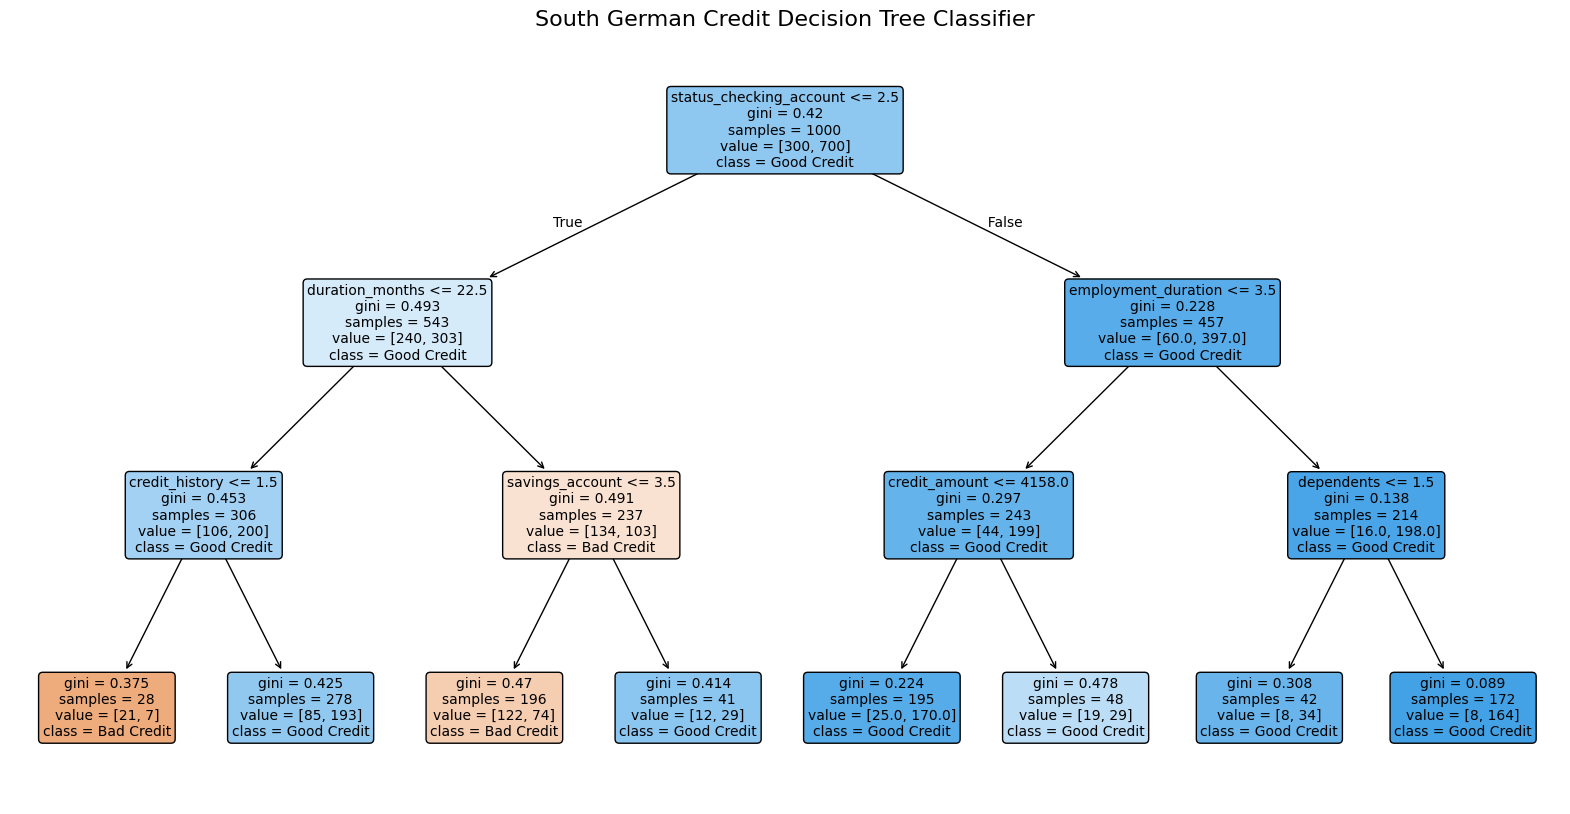

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Initialize and train Decision Tree (limiting max_depth=3 keeps the chart legible for screenshots)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# 2. Plot the tree graphically
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['Bad Credit', 'Good Credit'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("South German Credit Decision Tree Classifier", fontsize=16)
plt.show()

In [10]:
# Extract variable importance scores
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance[importance['Importance'] > 0])

                    Feature  Importance
0   status_checking_account    0.546763
1           duration_months    0.146200
2            credit_history    0.114586
5           savings_account    0.084161
4             credit_amount    0.062971
6       employment_duration    0.029350
17               dependents    0.015969
